# Day 3: Training My First Custom YOLO11 Model

**Date:** May 19, 2026  
**Goal:** Learn how to train a YOLO model from a pre-trained checkpoint.

This notebook shows the complete process of fine-tuning YOLO11 on a dataset.

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:00


In [2]:
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import torch
from roboflow import Roboflow

print("Setup Complete!")
print("GPU Available:", torch.cuda.is_available())


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup Complete!
GPU Available: True


In [4]:
# Easiest way - Small dataset for beginners
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/datasets.zip -O datasets.zip
!unzip -q datasets.zip -d /content/

--2026-05-19 14:12:58--  https://github.com/ultralytics/assets/releases/download/v0.0.0/datasets.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-19 14:12:59 ERROR 404: Not Found.

[datasets.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of datasets.zip or
        datasets.zip.zip, and cannot find datasets.zip.ZIP, period.


## 2. Loading Pre-trained Model and Starting Training

We start with `yolo11s.pt` (small version) because it gives a good balance between speed and accuracy.

### Training Parameters Explanation:

- `data="coco8.yaml"` → Using a small built-in dataset for quick practice
- `epochs=10` → Number of times the model will see the data (small for fast training)
- `imgsz=640` → Image size (640x640 is standard)
- `batch=16` → How many images the model processes at once
- `name="my_first_training"` → Folder name where results will be saved

In [6]:
# Load pre-trained model
model = YOLO("yolo11s.pt")


results = model.train(
    data="coco8.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    name="my_first_training"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=my_first_training-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

Training Completed Successfully! ✅

## Testing the Newly Trained Model

Now we load our custom trained model and test it on new images.




✅ Model loaded successfully!

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 57.9ms
Speed: 3.7ms preprocess, 57.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


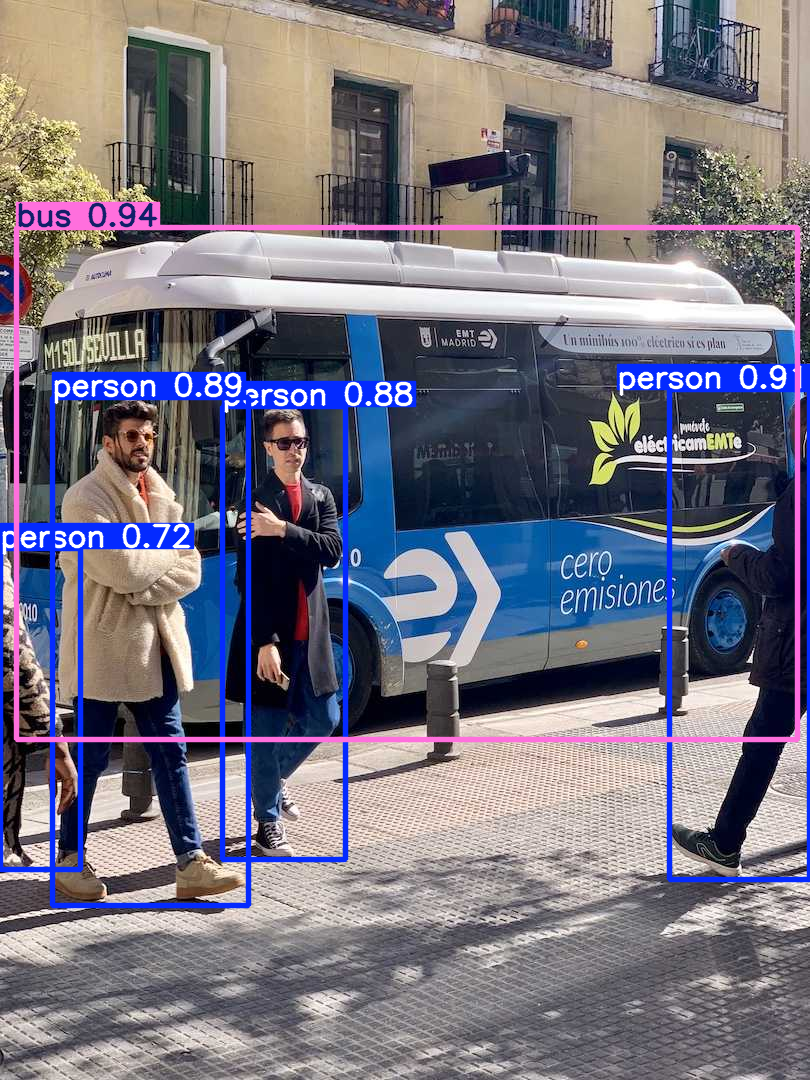

In [8]:
best_model = YOLO("/content/runs/detect/my_first_training/weights/best.pt")

print("✅ Model loaded successfully!")

results = best_model("https://ultralytics.com/images/bus.jpg", conf=0.25)


results[0].show()

##  Conclusion & Next Steps

**What I Learned Today:**
- How to train a YOLO11 model
- Understanding training parameters
- How to load and test a custom trained model
- File structure of YOLO training results

**Next Goals:**
- Train on a real custom dataset (e.g., Ethiopian vehicles, crops, hardhat, currency, etc.)
- Compare pre-trained vs custom model performance
- Create a Gradio web demo

---
**Repository:** [computer-vision-journey](https://github.com/Hayat373/computer-vision-journey)